# Understanding Numerical Summaries, Part 1: Measures of Location
This notebook generates select figures from the essay **Understanding Numerical Summaries, Part 1: Measures of Dispersion**. The essay expalins how the two most common measures of location, the mean and the median, are calculated and their relationship to process limits. 

To read the full essay visit [The Math Matters on Substack](https://themathmatters.substack.com/)

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

## Figure 1.
XmR chart of piston cylinder outer diameters

In [ ]:
# Piston cylinder dataset URL
piston_URL = r"https://raw.githubusercontent.com/jimlehner/The-Math-Matters/refs/heads/main/numerical-summaries-part-1-measures-of-location/data/piston-cylinder-outer-diameters.csv"

# Get data function
def get_data(dataset_url) -> pd.DataFrame:
    return pd.read_csv(dataset_url)

# Get the data
piston_df = get_data(piston_URL)

piston_df.head()

,Lathe,Part Number,Piston Cylinder OD
0,L3,1,92
1,L3,2,90
2,L3,3,90
3,L3,4,86
4,L3,5,54


In [123]:
# Cylinder diameters
diameters = piston_df["Piston Cylinder OD"]
# Calculate the moving range
diameter_mRs = diameters.diff().abs()
diameter_mRs.head()

0     NaN
1     2.0
2     0.0
3     4.0
4    32.0
Name: Piston Cylinder OD, dtype: float64

In [146]:
# Calculate process statistics
piston_mean = round(diameters.mean(), 2)
piston_ave_mR = round(diameter_mR.mean(), 2)

# Calculate process limits
piston_UPL = round(piston_mean + (2.660 * piston_ave_mR), 2)
piston_LPL = round(piston_mean - (2.660 * piston_ave_mR), 2)
piston_URL = round(3.268 * piston_ave_mR, 2)

print("Mean:", piston_mean)
print("Ave. moving range:", piston_ave_mR)
print("UPL:", piston_UPL)
print("UPL:", piston_LPL)
print("URL:", piston_URL)

Mean: 90.94
Ave. moving range: 7.12
UPL: 109.88
UPL: 72.0
URL: 23.27


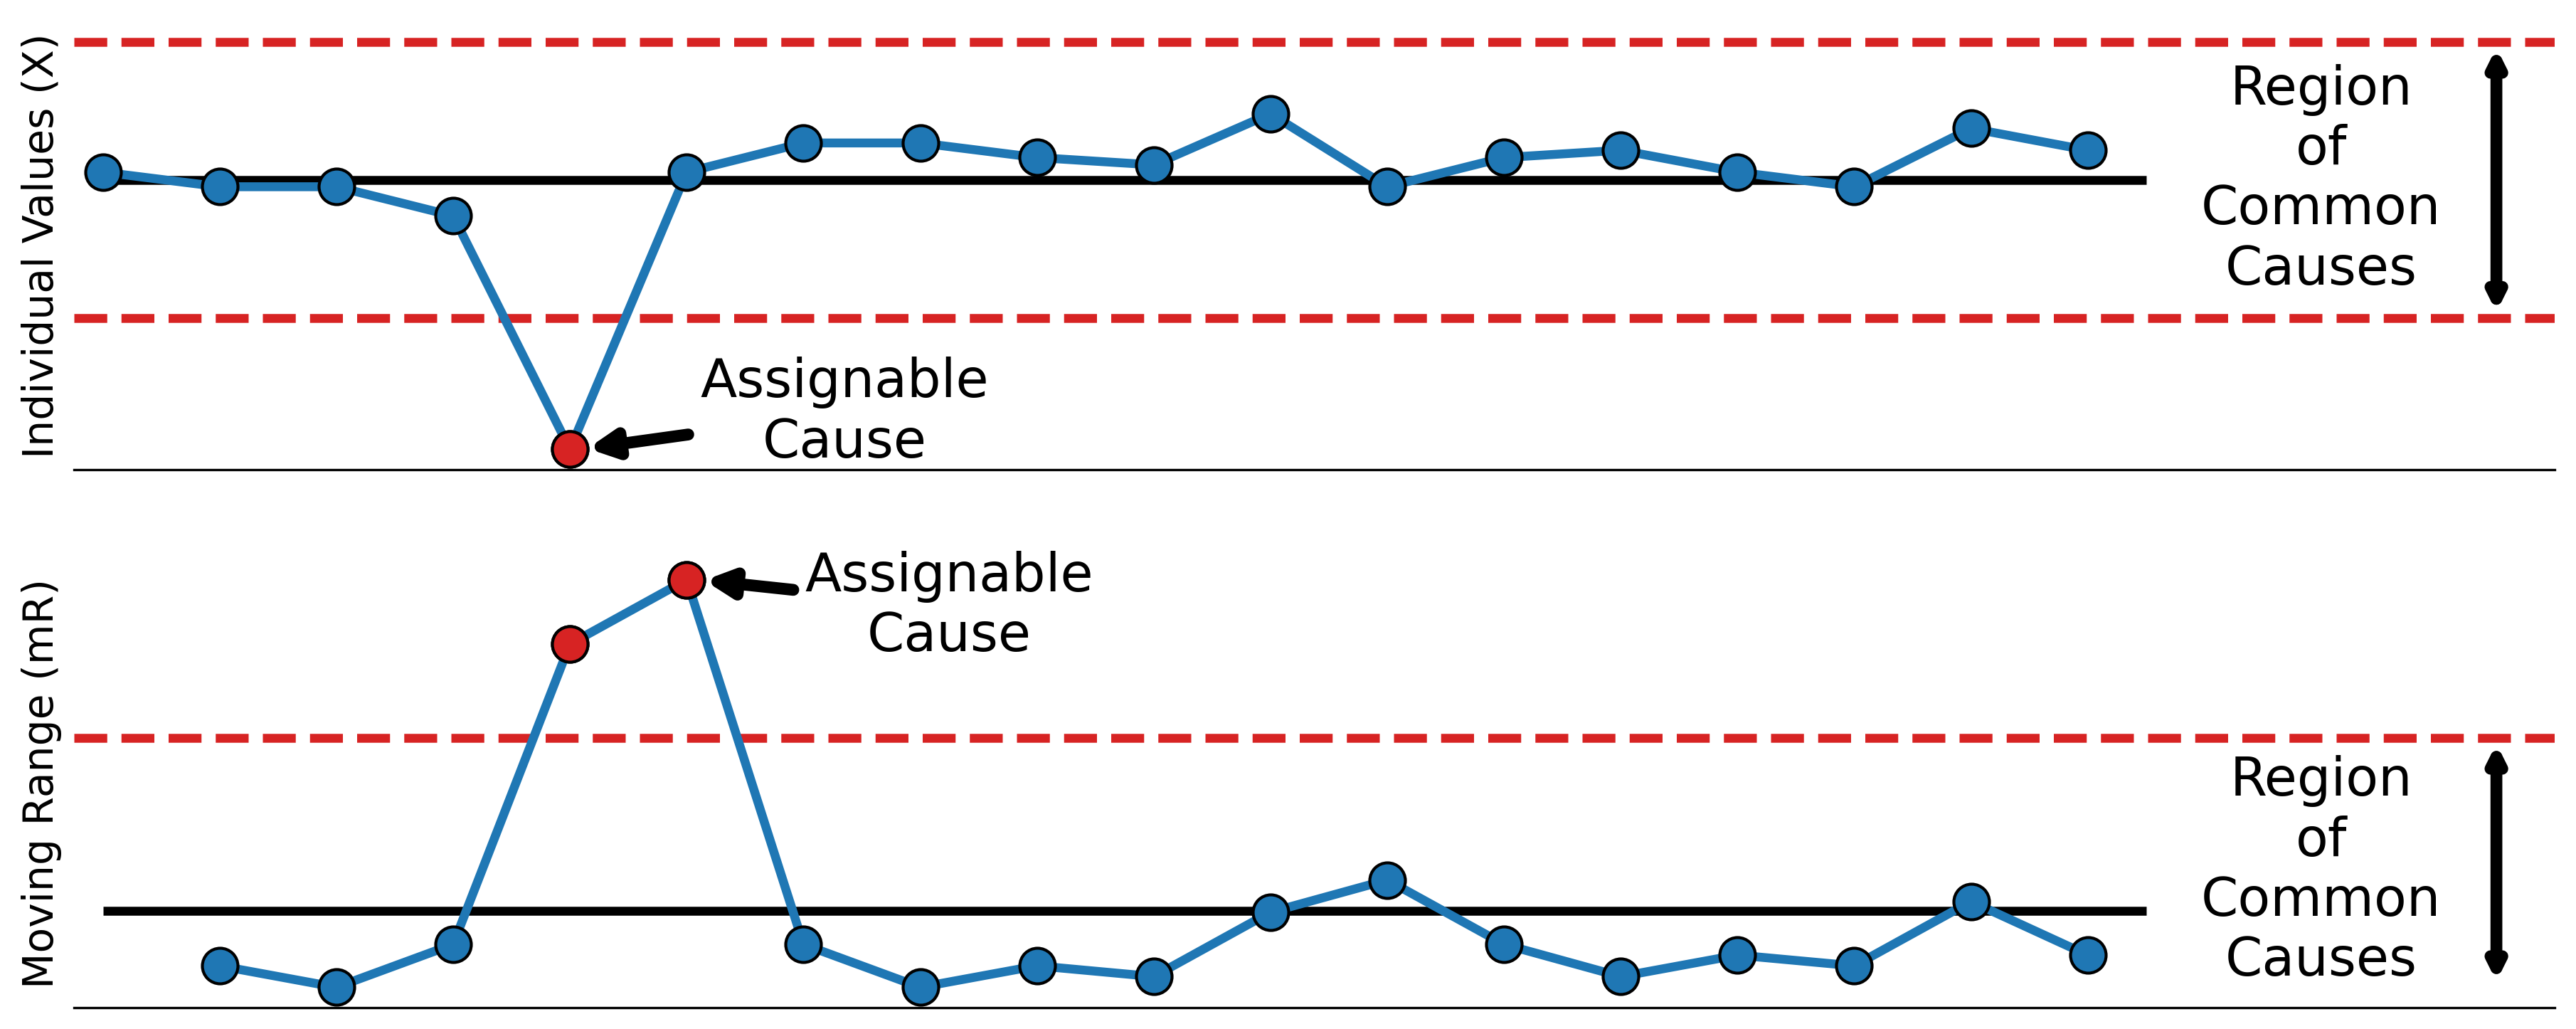

In [246]:
plots = [
    {
        "data": diameters,
        "center": piston_mean,
        "lower": piston_LPL,
        "upper": piston_UPL,
        "assignable_xy": (4.1, 54),
        "assignable_xytext": (6.35, 59),
        "region_text_y": piston_mean,
        "ylabel": "Individual Values (X)"
    },
    {
        "data": diameter_mRs,
        "center": piston_ave_mR,
        "lower": None,
        "upper": piston_URL,
        "assignable_xy": (5.1, 38),
        "assignable_xytext": (7.25, 35.5),
        "region_text_y": piston_URL / 2.15,
        "ylabel": "Moving Range (mR)"
    }
]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 6),
    sharex=True,
    dpi=300
)

for ax, plot in zip(axes, plots):

    data = plot["data"]
    center = plot["center"]
    lower = plot["lower"]
    upper = plot["upper"]
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_ylabel(
        plot["ylabel"],
        fontsize=14
    )
    
    # Plot all observations
    ax.plot(
        data,
        marker="o",
        markersize=12,
        markeredgecolor="black",
        linewidth=3,
        zorder=4
    )

    # Plot center line
    ax.hlines(
        center,
        xmin=0,
        xmax=17.5,
        linestyle="-",
        color="black",
        linewidth=3
    )

    # Highlight observations outside process limits
    if lower is not None:
        below_lpl = data < lower

        ax.plot(
            data[below_lpl],
            marker="o",
            markersize=12,
            markeredgecolor="black",
            markerfacecolor="#d72323",
            linestyle="none",
            zorder=5
        )

        ax.axhline(
            lower,
            linestyle="--",
            color="#d72323",
            linewidth=3
        )

    if upper is not None:
        above_upl = data > upper

        ax.plot(
            data[above_upl],
            marker="o",
            markersize=12,
            markeredgecolor="black",
            markerfacecolor="#d72323",
            linestyle="none",
            zorder=5
        )

        ax.axhline(
            upper,
            linestyle="--",
            color="#d72323",
            linewidth=3
        )

    # Assignable cause annotation
    ax.annotate(
        "Assignable\nCause",
        xy=plot["assignable_xy"],
        xytext=plot["assignable_xytext"],
        va="center",
        ha="center",
        fontsize=18,
        color="black",
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            linewidth=4
        )
    )

    # Region of common causes
    ax.text(
        19,
        plot["region_text_y"],
        "Region\nof\nCommon\nCauses",
        va="center",
        ha="center",
        fontsize=18,
        color="black"
    )

    # Double-headed arrow
    ax.annotate(
        "",
        xy=(20.5, upper),
        xytext=(20.5, lower if lower is not None else 0),
        arrowprops=dict(
            arrowstyle="<|-|>",
            color="black",
            linewidth=4
        )
    )

# Specify xlimits
axes[0].set_xlim(-0.25,21)

# Despine
sns.despine(left=True)

plt.show()

## Figure 3. 
The mean is the balance point of a dataset.

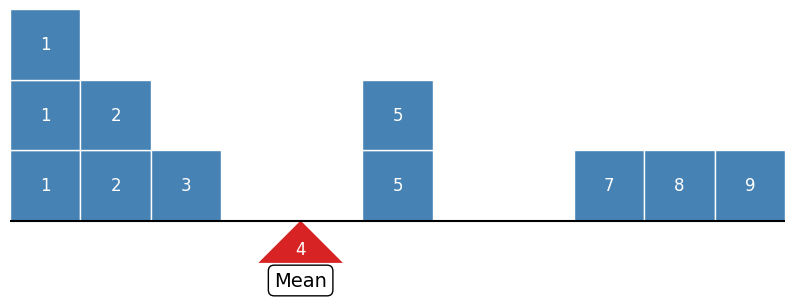

In [3]:
data = pd.Series([1, 9, 1, 5, 5, 2, 2, 8, 3, 7, 1])

data_arr = np.asarray(data)
counts, bin_edges = np.histogram(data_arr, bins=11)
bin_width = bin_edges[1] - bin_edges[0]
mean_val = data_arr.mean()

fig, ax = plt.subplots(figsize=(10, 5))
n_bins = len(bin_edges) - 1
for i in range(n_bins):
    left, right = bin_edges[i], bin_edges[i + 1]
    if i < n_bins - 1:
        in_bin = data_arr[(data_arr >= left) & (data_arr < right)]
    else:
        in_bin = data_arr[(data_arr >= left) & (data_arr <= right)]
    in_bin_sorted = np.sort(in_bin)
    for j, val in enumerate(in_bin_sorted):
        square = patches.Rectangle(
            (left, j), bin_width, 1,
            facecolor="steelblue", edgecolor="white"
        )
        ax.add_patch(square)
        ax.text(
            left + bin_width / 2, j + 0.5, f"{val:g}",
            ha="center", va="center", color="white", fontsize=12
        )

ax.set_xlim(bin_edges[0], bin_edges[-1])

triangle_height = counts.max() * 0.2
triangle_width = bin_width * 1.2

# extra room below for the "arithmetic mean" label
label_gap = triangle_height * 0.6
ax.set_ylim(-triangle_height * 1 - label_gap, counts.max())

triangle = patches.Polygon(
    [
        (mean_val - triangle_width / 2, -triangle_height),
        (mean_val + triangle_width / 2, -triangle_height),
        (mean_val, 0),
    ],
    closed=True, facecolor="#d72323"
)
ax.add_patch(triangle)

ax.text(
    mean_val, -triangle_height * (2 / 3), f"{mean_val:g}",
    ha="center", va="center", color="white", fontsize=12
)

# "arithmetic mean" label below the triangle's base
ax.text(
    mean_val, -triangle_height - label_gap * 0.5, "Mean",
    ha="center", va="center", color="black", fontsize=12
)

ax.annotate(
    "Mean",
    xy=(4,-0.85),
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(facecolor="white",
             edgecolor="black",
             boxstyle="round")
           )

ax.axhline(0, color="black")

ax.set_aspect(bin_width)
sns.despine(left=True, bottom=True)
ax.grid(axis='y', color='white')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_xticks([])

plt.show()

## Figure 4. 
The median defines the 50th percentile of a dataset

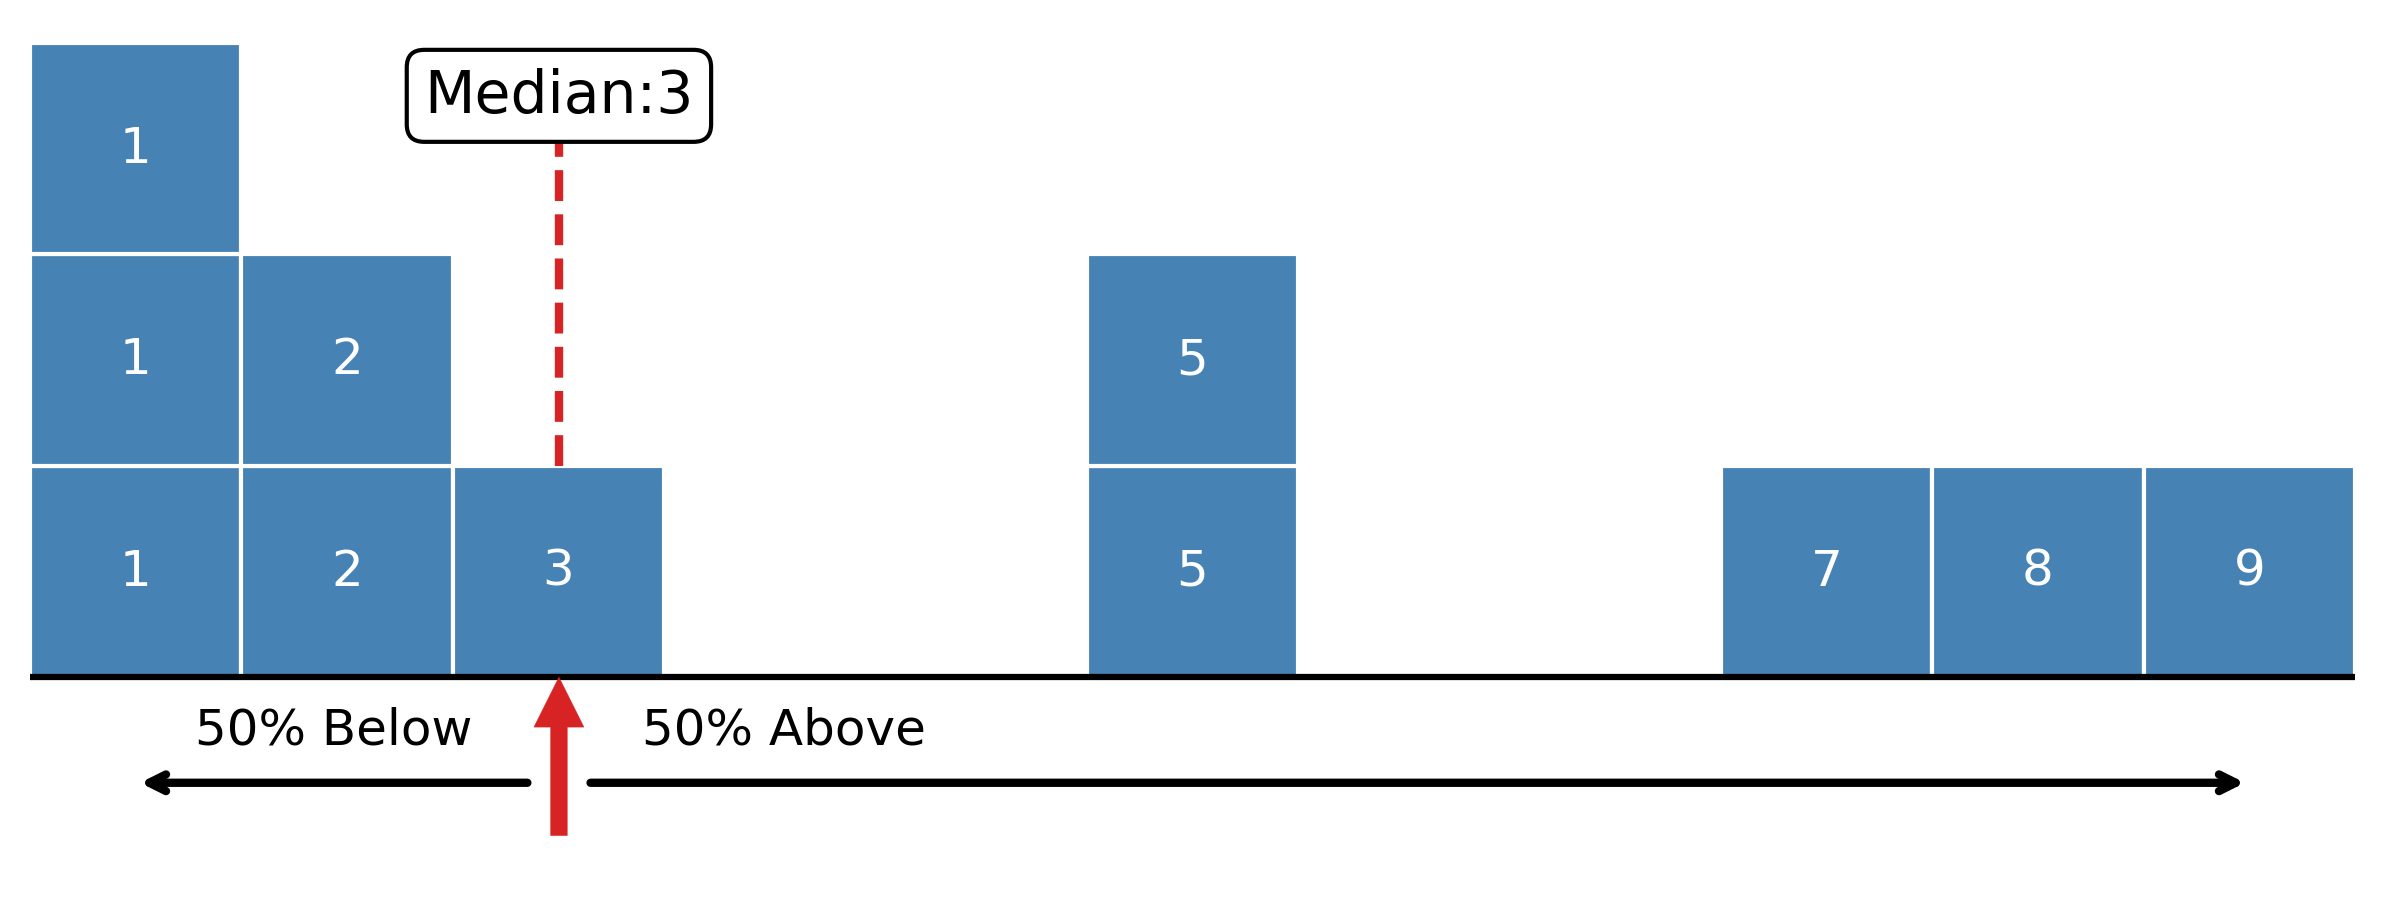

In [4]:
data = pd.Series([1, 9, 1, 5, 5, 2, 2, 8, 3, 7, 1])

data_arr = np.asarray(data)
counts, bin_edges = np.histogram(data_arr, bins=11)
bin_width = bin_edges[1] - bin_edges[0]
median_val = np.median(data_arr)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
n_bins = len(bin_edges) - 1
for i in range(n_bins):
    left, right = bin_edges[i], bin_edges[i + 1]
    if i < n_bins - 1:
        in_bin = data_arr[(data_arr >= left) & (data_arr < right)]
    else:
        in_bin = data_arr[(data_arr >= left) & (data_arr <= right)]
    in_bin_sorted = np.sort(in_bin)
    for j, val in enumerate(in_bin_sorted):
        square = patches.Rectangle(
            (left, j), bin_width, 1,
            facecolor="steelblue", edgecolor="white"
        )
        ax.add_patch(square)
        ax.text(
            left + bin_width / 2, j + 0.5, f"{val:g}",
            ha="center", va="center", color="white", fontsize=12
        )

ax.set_xlim(bin_edges[0], bin_edges[-1])

# extra room below for the "arithmetic mean" label
label_gap = triangle_height * 0.6
ax.set_ylim(-triangle_height - label_gap, counts.max())

ax.text(
    median_val, -triangle_height * (2 / 3), f"{median_val:g}",
    ha="center", va="center", color="white", fontsize=12
)

ax.text(
    2.82, 2.95, f"{median_val:g}",
    ha="center", va="center", color="white", fontsize=12
)

ax.text(
    2.045, -.25, "50% Below",
    ha="center", va="center", color="black", fontsize=12
)

ax.text(
    3.595, -.25, "50% Above",
    ha="center", va="center", color="black", fontsize=12
)

ax.axhline(0, color="black")

ax.set_aspect(bin_width)
sns.despine(left=True, bottom=True)
ax.grid(axis='y', color='white')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_xticks([])

# 50% below arrow
ax.annotate(
    "", xy=(2.74, -0.5), xytext=(1.35, -0.5),
    arrowprops=dict(arrowstyle="<-", lw=2, color="black")
)

# 50% above arrow
ax.annotate(
    "", xy=(2.9, -0.5), xytext=(8.65, -0.5),
    arrowprops=dict(arrowstyle="<-", lw=2, color="black")
)

# Add vertical arrow at Median below 
ax.annotate(
    '',
    xy=(2.82,0),
    xytext=(2.82,-0.75),
    arrowprops=dict(color="#d72323",lw=0.1),
    zorder=2
)

ax.vlines(2.82, ymin=1, ymax=2.75, color="#d72323", ls="--", lw=2)

ax.annotate(
    "Median:3",
    xy=(2.82,2.75),
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(facecolor="white",
             edgecolor="black",
             boxstyle="round")
           )

plt.show()

## Figure 5. 
X charts of the same data with limits calculated using the mean and average moving range (left) and the median and median moving range (right).

In [ ]:
# Dataset URL
hydrix_url = r'https://raw.githubusercontent.com/jimlehner/The-Math-Matters/refs/heads/main/numerical-summaries-part-1-measures-of-location/data/hydrix-cell-voltage.csv'

# Get data
df = get_data(hydrix_url)
df.head()

,Supplier,Supplier-Sample,Cell Voltage (mV)
0,Hydrix,A-1,671.06
1,Hydrix,A-2,678.02
2,Hydrix,A-3,659.32
3,Hydrix,A-4,676.15
4,Hydrix,A-5,677.73


In [65]:
# Get cell voltage data
cell_voltage = df["Cell Voltage (mV)"]

# Calculate mean and median for cell voltage
mean = round(cell_voltage.mean(), 2)
median = round(cell_voltage.median(), 2)

print("Mean:", mean)
print("Median:", median)

Mean: 673.79
Median: 676.61


In [26]:
# Calculate the moving range
mR = abs(df["Cell Voltage (mV)"].diff())
mR.head()

0      NaN
1     6.96
2    18.70
3    16.83
4     1.58
Name: Cell Voltage (mV), dtype: float64

In [27]:
# Calculate average moving range and median moving range
ave_mR = round(mR.mean(), 2)
med_mR = round(mR.median(), 2)

print("Average moving range:", ave_mR)
print("Median moving range:", med_mR)

Average moving range: 8.84
Median moving range: 3.6


In [66]:
# Calculate process limits using mean ± (2.660 • Average mR)
mean_UPL = round(mean + (2.660 * ave_mR), 2)
mean_LPL = round(mean - (2.660 * ave_mR), 2)

print("Mean UPL:", mean_UPL)
print("Mean LPL:", mean_LPL)

Mean UPL: 697.3
Mean LPL: 650.28


In [67]:
# Calculate process limits using median ± (3.145 • Median mR)
median_UPL = round(median + (3.145 * med_mR), 2)
median_LPL = round(median - (3.145 * med_mR), 2)

print("Median UPL:", median_UPL)
print("Median LPL:", median_LPL)

Median UPL: 687.93
Median LPL: 665.29


In [248]:
# Subplot values
# Values for each subplot
methods = [
    {
        "title": "Mean ± (2.660 • $\mathrm{\overline{mR}}$)",
        "location": mean,
        "upper": mean_UPL,
        "central": mean,
        "lower": mean_LPL,
        "label": "Mean"
    },
    {
        "title": r"Median ± (3.145 • $\widetilde{\mathrm{mR}}$)",
        "location": median,
        "upper": median_UPL,
        "lower": median_LPL,
        "label": "Median"
    }
]

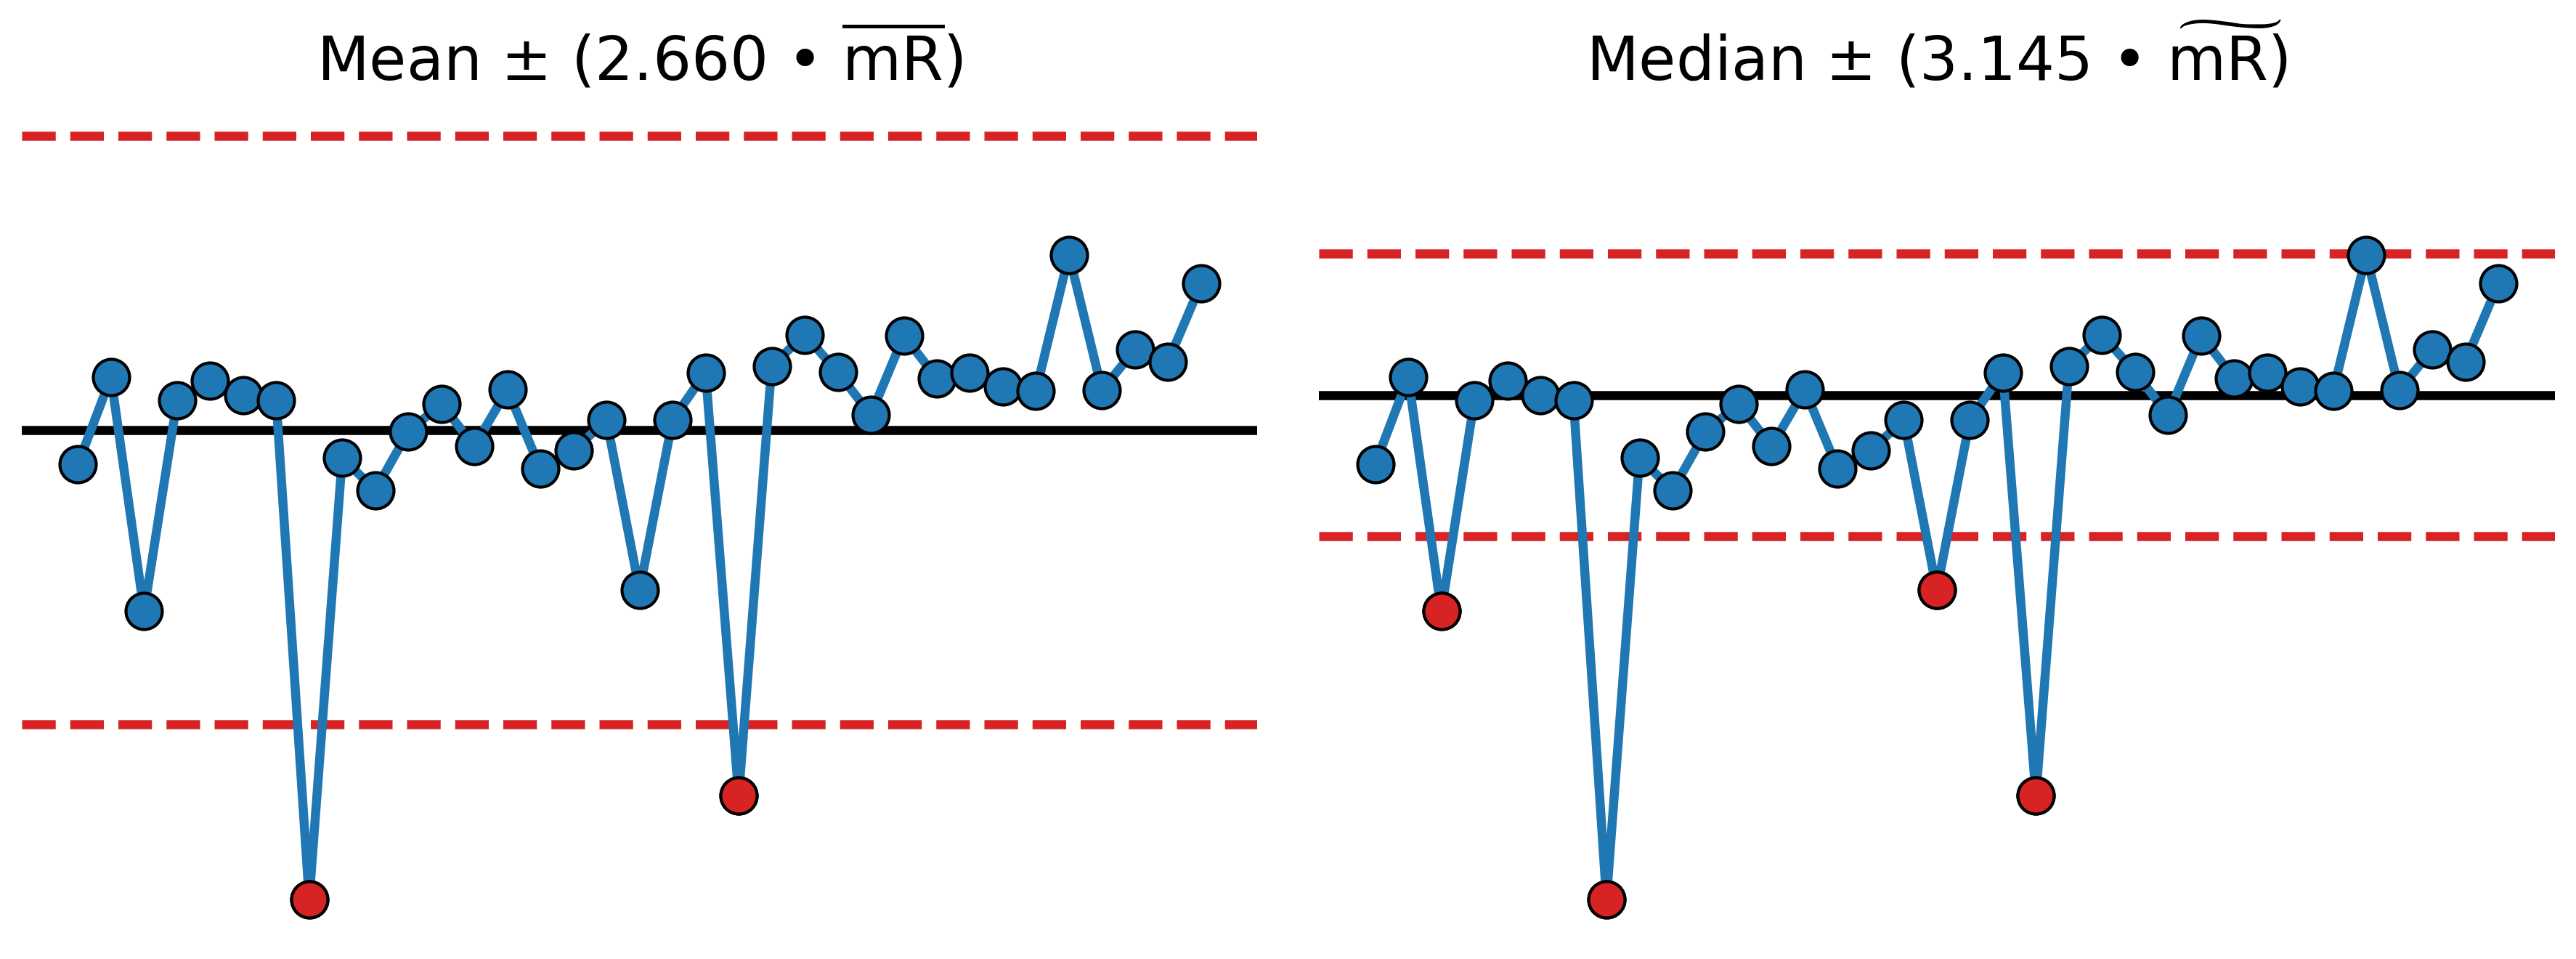

In [249]:

fig, axes = plt.subplots(nrows=1, 
                         ncols=2, 
                         figsize=(15,5), 
                         sharey=True, 
                         dpi=300)

# Adjust whitespace between subplots
plt.subplots_adjust(wspace=0.05)

# Plot the data and limits
for ax, method in zip(axes, methods):
    ax.plot(
        cell_voltage,
        marker="o",
        markersize=12,
        markeredgecolor='black',
        linewidth=3, 
        zorder=4
    )
    
    # Highlight values less than the lower process limits (LPLs)
    below_lpl = cell_voltage < method["lower"]
    
    # Highlight values less than the LPL
    ax.plot(
        cell_voltage[below_lpl],
        marker="o",
        markersize=12,
        markeredgecolor="black",
        markerfacecolor="#d72323",
        linestyle="none",
        zorder=5
    )
    
    ax.axhline(
        method["location"],
        linestyle="-",
        color="black",
        linewidth=3
    )
    
    # Add the process limits
    for limit in ["upper", "lower"]:
        ax.axhline(
            method[limit],
            linestyle="--",
            color="#d72323",
            linewidth=3,
            label="Process limit" if limit == "upper" else None
        )
    
    # Add the titles
    ax.set_title(
        method["title"], 
        fontsize=20)
    
    ax.set_xticks([])
    ax.set_yticks([])

sns.despine(left=True, bottom=True)
        
plt.show()